## ELASTIC-NET REGRESSİON

In [1]:
#Gerekli kütüphaneleri indirelim.
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seabornInstance
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline
import matplotlib
matplotlib.rcParams.update({"font.size":12})
from sklearn.linear_model import ElasticNet


In [2]:
# Veri setini indirelim.
veri= pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)
veri.head()

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [3]:
# Hedef ve öznitelik değişkenlerini (x) tanımlayalım,Veriyi bölelim:
x=veri [["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y=veri["Fiyat"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [4]:
#ElasticNet algoritmasını eğitiyoruz:
enet=ElasticNet()
enet.fit(x_train,y_train)
train_score=enet.score(x_train,y_train)
test_score=enet.score(x_test,y_test)
coeff_used=np.sum(enet.coef_!=0)

In [11]:
#Algoritmanın otomatik olarak atanan parametrelerine bakalım.
enet # deault alpha değeri 0.5 dir.
print("Eğitim verisi için R2 :",round(train_score,4))
print("Test verisi için R2 :",round(test_score,4))
print("Katsayısı sıfır olmayan öznitelik sayısı: ",coeff_used)


Eğitim verisi için R2 : 0.6709
Test verisi için R2 : 0.5628
Katsayısı sıfır olmayan öznitelik sayısı:  4


In [12]:
#ElasticNet (alpha=0.01):
enet001= ElasticNet(alpha=0.01,max_iter=100000)
enet001.fit(x_train,y_train)
 
train_score001=enet001.score(x_train,y_train)
test_score001= enet001.score(x_test,y_test)
coeff_used001=np.sum(enet001.coef_!=0)

print("Eğitim verisi için R2 (alpha=0.01):",round(train_score001,4))
print("Test verisi için R2 (alpha=0.01):",round(test_score001,4))
print("Katsayısı sıfır olmayan öznitelik sayısı (alpha=0.01):",coeff_used)

Eğitim verisi için R2 (alpha=0.01): 0.7334
Test verisi için R2 (alpha=0.01): 0.6923
Katsayısı sıfır olmayan öznitelik sayısı (alpha=0.01): 4


In [13]:
#ElasticNet (alpha=100):
enet100=ElasticNet(alpha=100,max_iter=100000)
enet100.fit(x_train,y_train)

train_score100=enet100.score(x_train,y_train)
test_score100=enet100.score(x_test,y_test)
coeff_used100=np.sum(enet100.coef_!=0)

print("Eğitim verisi için R2 (alpha=100):",round(train_score100,4))
print("Test verisi için R2 (alpha=100):",round(test_score100,4))
print("Katsayısı sıfır olmayan öznitelik sayısı (alpha=100):",coeff_used100)

Eğitim verisi için R2 (alpha=100): 0.5845
Test verisi için R2 (alpha=100): 0.4775
Katsayısı sıfır olmayan öznitelik sayısı (alpha=100): 3


In [16]:
#Doğrusal regresyon tahmini
lr=LinearRegression()
lr.fit(x_train,y_train)
lr_train_score=lr.score(x_train,y_train)
lr_test_score=lr.score(x_test,y_test)

print("Eğitim setinin R2 si",round(lr_train_score,4))
print("Test setinin R2 si: ",round(lr_test_score,4))

Eğitim setinin R2 si 0.7337
Test setinin R2 si:  0.6987


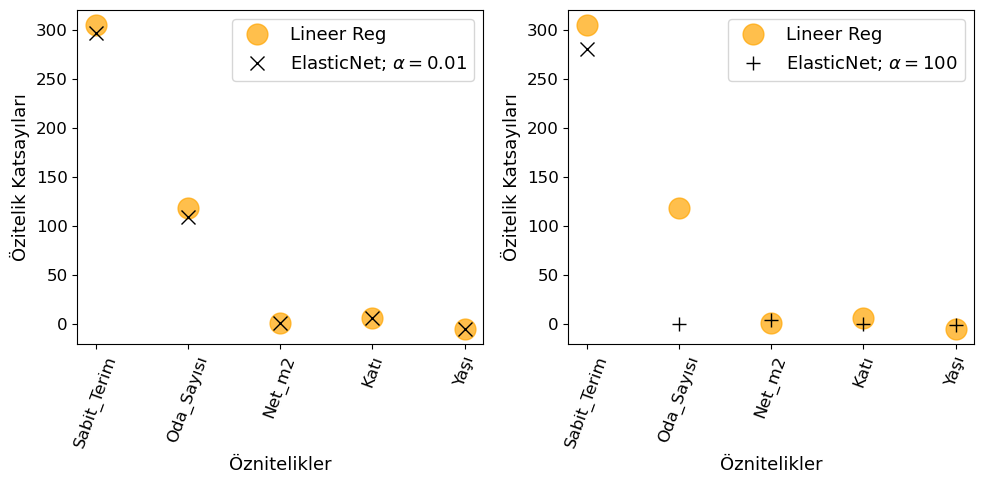

In [18]:
# Grafikleri karşılaştırma
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot((1,2,3,4),lr.coef_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange",label="Lineer Reg",zorder=2)
plt.plot((1,2,3,4),enet001.coef_,alpha=1,linestyle="none",marker="x",markersize=10,color="black",label=r"ElasticNet; $\alpha =0.01$",zorder=7)
plt.plot(0,lr.intercept_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange")
plt.plot(0,enet001.intercept_,alpha=1,linestyle="none",marker="x",markersize=10,color="black")

plt.xticks([0,1,2,3,4],("Sabit_Terim","Oda_Sayısı","Net_m2","Katı","Yaşı"),rotation=70)
plt.xlabel("Öznitelikler",fontsize=13)
plt.ylabel("Özitelik Katsayıları",fontsize=13)
plt.legend(fontsize=13,loc="upper right")
plt.subplot(1,2,2)

plt.plot((1,2,3,4),lr.coef_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange",label="Lineer Reg",zorder=2)
plt.plot((1,2,3,4),enet100.coef_,alpha=1,linestyle="none",marker="+",markersize=10,color="black",label=r"ElasticNet; $\alpha =100$")
plt.plot(0,lr.intercept_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange")
plt.plot(0,enet100.intercept_,alpha=1,linestyle="none",marker="x",markersize=10,color="black")

plt.xticks([0,1,2,3,4],("Sabit_Terim","Oda_Sayısı","Net_m2","Katı","Yaşı"),rotation=70)
plt.xlabel("Öznitelikler",fontsize=13)
plt.ylabel("Özitelik Katsayıları",fontsize=13)
plt.legend(fontsize=13,loc="upper right")
plt.tight_layout()
plt.show()